# Anchored Langevin on a non-differentiable heavy-tailed target

Self-contained: `numpy`, `scipy`, `matplotlib` only.

The target is heavy tailed **and** non-differentiable at the same time — a
$d=3$ Student-t core ($\nu=6$, $\kappa=100$) plus the **minimax concave
penalty** (MCP) of Zhang (2010):

$$U = \iota\log q + \sum_i p_\lambda(x_i),\qquad
  U_0 = \beta\log q + \sum_i p^{\varepsilon}_\lambda(x_i),$$

$$p_\lambda(t) = \begin{cases}\lambda|t| - t^2/(2a) & |t|\le a\lambda\\
 a\lambda^2/2 & \text{otherwise,}\end{cases}$$

and $p^{\varepsilon}_\lambda$ its smoothing (the paper's Eq. 67). Two properties
make this the right test object: $p_\lambda$ is **non-differentiable at the
origin**, so $\nabla U$ does not exist there and plain ULA is ill defined; and
$p_\lambda$ is **bounded**, so $e^{-U}$ keeps the Student-t's polynomial tail —
which also gives an exact i.i.d. sampler by rejection from the core, with
acceptance $e^{-\sum_i p_\lambda(x_i)}$.

The anchor $U_0$ takes the *smoothed* penalty, so $\nabla U_0$ exists
everywhere and the sampler never differentiates the kink. The two runs are
$J = 0$ and a constant skew $J_a$, from each of the two starting ensembles
$N(0,10I_d)$ and $\mathrm{Uniform}(-5,5)^d$.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
# ---- parameters ---------------------------------------------------------
D, NU, KAPPA = 3, 6.0, 100.0        # Student-t core
LAM, A_MCP, EPS = 1.0, 2.0, 0.1     # MCP: lambda, a, and the smoothing eps
A = 4.0                             # field strength: J_a has spectral norm A
N, REPS, STEPS = 5000, 5, 20000     # particles, replications, iterations
RAMP = 20.0                         # warm-up of the skew field, in fast relaxations.
# 20, not the 10 that suffices on the smooth target: measured on this target the
# uniform prior rises 1.399x out of a trough at ramp 10 and 1.000x at ramp 20,
# at the same 991 iterations either way -- so the longer hold is free. The
# Gaussian prior is flat at both (794 iterations). A ramp calibrated on one
# prior and one target does not automatically transfer to another.
PRIORS = ("normal10", "uniform5")   # X_0 ~ N(0, 10 I)  and  X_0 ~ Uniform(-5, 5)^d

# Stepsizes: the equal-bias values of the SMOOTH core, from the exact
# second-moment recursion at 2% stationary covariance bias.  The composite
# potential is not log-quadratic, so its own recursion is not exact and the
# equal-bias property is approximate -- this is the protocol of exp4.
ETA = {"zero": 1.098755e-03, "const": 5.120846e-04}

## The Student-t core

In [3]:
class StudentT:
    """Student-t pi ~ q^{-iota} with the log-quadratic anchor U0 = beta log q.

        q(x)  = 1 + (1/nu) x' Sigma^-1 x
        U     = iota log q,   iota = (d + nu) / 2
        U0    = beta log q,   beta = iota - 1
        e^{U-U0} = q,  grad U0 = (2 beta/nu) Sigma^-1 x / q
        drift b = -e^{U-U0} grad U0 = -(2 beta/nu) Sigma^-1 x     (linear: q cancels)
        sigma(x) = sqrt(q)
    """

    def __init__(self, d, nu, kappa):
        self.d, self.nu = d, float(nu)
        # log-spaced eigenvalues spanning the condition number, largest = 1
        self.Sigma = np.diag(np.logspace(-np.log10(kappa), 0.0, d))
        self.Sigma_inv = np.linalg.inv(self.Sigma)
        ev, V = np.linalg.eigh(self.Sigma)
        self.Sigma_evals, self.Sigma_evecs = ev, V
        self.Sigma_half = (V * np.sqrt(ev)) @ V.T
        self.iota = 0.5 * (d + self.nu)
        self.beta = self.iota - 1.0
        self.coef = 2.0 * self.beta / self.nu

    def q(self, x):
        x = np.atleast_2d(x)
        return 1.0 + np.einsum("ni,ij,nj->n", x, self.Sigma_inv, x) / self.nu

    def grad_U0(self, x):
        x = np.atleast_2d(x)
        return self.coef * (x @ self.Sigma_inv) / self.q(x)[:, None]

    def anchor_scale(self, x):
        return self.q(x)

    def sigma(self, x):
        return np.sqrt(self.q(x))

    def sample(self, n, rng):
        z = rng.standard_normal((n, self.d))
        g = rng.chisquare(self.nu, size=n)
        return (z @ self.Sigma_half) * np.sqrt(self.nu / g)[:, None]

    def projected_scale(self, theta):
        return float(np.sqrt(theta @ self.Sigma @ theta))

    def projected_ppf(self, u, theta):
        return stats.t.ppf(u, df=self.nu, scale=self.projected_scale(theta))

    def projected_isf(self, w, theta):
        return stats.t.isf(w, df=self.nu, scale=self.projected_scale(theta))


## The MCP penalty, and the composite target

`StudentTMCP` inherits the core and overrides only what the penalty changes:
`grad_U0` gains the smoothed penalty's gradient, `anchor_scale` gains the
bounded factor $\exp(\sum_i[p_\lambda - p^{\varepsilon}_\lambda])$, and `sample`
becomes rejection from the core.

In [4]:
def mcp(t, lam, a):
    """MCP of Zhang (2010): non-differentiable at 0, and bounded."""
    t = np.abs(np.asarray(t, float))
    return np.where(t <= a * lam, lam * t - t * t / (2.0 * a), 0.5 * a * lam * lam)


def mcp_smoothed(t, lam, a, eps):
    """The paper's Eq. 67 smoothing of the MCP."""
    t = np.asarray(t, float)
    r = np.sqrt(a * a * lam * lam + eps * eps)
    inner = lam * np.sqrt(t * t + eps * eps) - lam * t * t / (2.0 * r)
    outer = lam * (a * a * lam * lam + 2.0 * eps * eps) / (2.0 * r)
    return np.where(np.abs(t) <= a * lam, inner, outer)


def mcp_smoothed_grad(t, lam, a, eps):
    t = np.asarray(t, float)
    r = np.sqrt(a * a * lam * lam + eps * eps)
    inner = lam * t / np.sqrt(t * t + eps * eps) - lam * t / r
    return np.where(np.abs(t) <= a * lam, inner, 0.0)


class StudentTMCP(StudentT):
    """U  = iota log q + sum_i p_lam(x_i)        non-differentiable at x_i = 0
       U0 = beta log q + sum_i p^eps_lam(x_i)    C^1, the anchor"""

    def __init__(self, d, nu, kappa, lam=1.0, a=2.0, eps=0.1):
        super().__init__(d, nu, kappa)
        self.lam, self.a, self.eps = float(lam), float(a), float(eps)

    def penalty(self, x):
        return np.sum(mcp(x, self.lam, self.a), axis=-1)

    def penalty_smoothed(self, x):
        return np.sum(mcp_smoothed(x, self.lam, self.a, self.eps), axis=-1)

    def grad_U0(self, x):
        x = np.atleast_2d(x)
        return super().grad_U0(x) + mcp_smoothed_grad(x, self.lam, self.a, self.eps)

    def anchor_scale(self, x):
        x = np.atleast_2d(x)
        return self.q(x) * np.exp(self.penalty(x) - self.penalty_smoothed(x))

    def sigma(self, x):
        return np.sqrt(self.anchor_scale(x))

    def sample(self, n, rng, max_rounds=200):
        """Exact i.i.d. draws by rejection from the Student-t core.
        exp(-penalty) <= 1 bounds the ratio, so the acceptance is exact."""
        out, got = [], 0
        for _ in range(max_rounds):
            m = max(int(1.6 * (n - got)), 1024)
            prop = super().sample(m, rng)
            acc = prop[rng.random(m) < np.exp(-self.penalty(prop))]
            out.append(acc); got += acc.shape[0]
            if got >= n:
                break
        else:
            raise RuntimeError("rejection sampler did not reach n draws")
        return np.concatenate(out, axis=0)[:n]


## The skew matrix

In [5]:
def _constant_diagonal_basis(A, tol=1e-12):
    """Orthogonal Q with diag(Q A Q') constant, by Bendel-Mickey rotations."""
    A = np.asarray(A, float); d = A.shape[0]
    target = np.trace(A) / d
    N, Q = A.copy(), np.eye(d)
    fixed = np.zeros(d, bool)
    for _ in range(d - 1):
        free = np.where(~fixed)[0]
        diag = np.diag(N)[free]
        if np.all(np.abs(diag - target) < tol):
            break
        i, j = free[int(np.argmin(diag))], free[int(np.argmax(diag))]
        p, q_, r = N[i, i], N[j, j], N[i, j]
        if abs(p - target) < tol:
            fixed[i] = True
            continue
        a2, b2, c2 = q_ - target, 2.0 * r, p - target
        if abs(a2) < tol:
            t = -c2 / b2 if abs(b2) > tol else 0.0
        else:
            disc = max(b2 * b2 - 4.0 * a2 * c2, 0.0)
            t = min([(-b2 + np.sqrt(disc)) / (2 * a2),
                     (-b2 - np.sqrt(disc)) / (2 * a2)], key=abs)
        c = 1.0 / np.sqrt(1.0 + t * t); s = t * c
        G = np.eye(d); G[i, i] = G[j, j] = c; G[i, j] = s; G[j, i] = -s
        N = G @ N @ G.T; Q = G @ Q
        fixed[i] = True
    return Q


def optimal_skew(A):
    """Skew J making every eigenvalue of (I - J)A equal to Tr(A)/d."""
    A = np.asarray(A, float); d = A.shape[0]
    if d < 2:
        return np.zeros((d, d))
    ev, V = np.linalg.eigh(A)
    A_inv_half = (V * (1.0 / np.sqrt(ev))) @ V.T
    Q = _constant_diagonal_basis(A)
    L = np.tril(Q @ A @ Q.T, -1)
    K = A_inv_half @ (Q.T @ (L.T - L) @ Q) @ A_inv_half
    return -0.5 * (K - K.T)


## The sampler

Identical to the smooth case — the anchored step only ever touches $U_0$, which
is $C^1$ by construction. That is the whole point of the anchoring: the kink in
$U$ never enters the drift.

In [6]:
def make_prior(kind, d, n, rng):
    """The two starting ensembles.

        normal10   X_0 ~ N(0, 10 I_d)          covariance 10 I
        uniform5   X_0 ~ Uniform(-5, 5)^d      covariance (100/12) I = 8.33 I
    """
    if kind == "normal10":
        return rng.standard_normal((n, d)) * np.sqrt(10.0)
    if kind == "uniform5":
        return rng.uniform(-5.0, 5.0, size=(n, d))
    raise ValueError(f"unknown prior {kind!r}")


def warmup_schedule(target, eta, n_relax=10.0):
    """Smoothstep over n_relax relaxations of the fastest direction."""
    k_relax = 1.0 / (eta * target.coef / target.Sigma_evals.min())
    K = max(1.0, n_relax * k_relax)

    def sched(k):
        u = min(1.0, k / K)
        return u * u * (3.0 - 2.0 * u)
    return sched


def anchored_step(target, eta, J=None, schedule=None):
    """Euler-Maruyama for dX = [-I + J] e^{U-U0} grad U0 dt + sqrt(2) sigma dW."""
    sq = np.sqrt(2.0 * eta)
    counter = {"k": 0}

    def step(x, rng):
        s_k = 1.0 if schedule is None else float(schedule(counter["k"]))
        counter["k"] += 1
        g = target.grad_U0(x)
        rot = g if J is None else g @ J.T
        drift = target.anchor_scale(x)[:, None] * ((0.0 if J is None else s_k) * rot - g)
        return x + eta * drift + sq * (target.sigma(x)[:, None] * rng.standard_normal(x.shape))
    return step


## The metric

The composite target has no closed-form projected quantiles — the penalty
breaks the Student-t structure — so the reference side is an exact i.i.d.
*sample* rather than an exact quantile function, and the distance is the
two-sample sliced $W_2$. That estimator has a noise floor even for two exact
samples, so the floor is measured and reported alongside the curves.

In [7]:
def w2_sq_1d_two_sample(x, y):
    """W2^2 between two equal-size empirical samples on the line."""
    x = np.sort(np.asarray(x, float).ravel())
    y = np.sort(np.asarray(y, float).ravel())
    if x.size != y.size:
        n = min(x.size, y.size)
        u = (np.arange(n) + 0.5) / n
        x, y = np.quantile(x, u), np.quantile(y, u)
    return float(np.mean((x - y) ** 2))


def sliced_w2_two_sample(x, y, d):
    """The MCP target has no closed-form projected quantiles, so the reference
    side is an exact sample rather than an exact quantile function."""
    total = sum(w2_sq_1d_two_sample(x @ th, y @ th) for th in np.eye(d))
    return float(np.sqrt(total / d))


In [8]:
def log_schedule(n_steps, n_points=90):
    pts = np.unique(np.round(np.geomspace(1, n_steps, n_points)).astype(int))
    return sorted(set([0] + pts.tolist() + [n_steps]))


## Run

In [9]:
target = StudentTMCP(D, NU, KAPPA, lam=LAM, a=A_MCP, eps=EPS)
J_opt = optimal_skew(target.Sigma_inv)
J_a = A * J_opt / np.linalg.norm(J_opt, 2)          # spectral norm exactly A
record_at = log_schedule(STEPS, 90)

rng = np.random.default_rng(0)
prop = StudentT(D, NU, KAPPA).sample(200_000, rng)
print(f"Sigma eigenvalues        : {np.sort(target.Sigma_evals)}")
print(f"iota = {target.iota}, beta = {target.beta}")
print(f"rejection acceptance rate: {np.mean(np.exp(-target.penalty(prop))):.3f}")

# the reference sample the curves are measured against, and the estimator floor
reference = target.sample(N, rng)
floor = np.mean([sliced_w2_two_sample(target.sample(N, rng), target.sample(N, rng), D)
                 for _ in range(6)])
print(f"two-sample sliced-W2 floor at n={N}: {floor:.4f}")
print(f"\nJ_a (spectral norm {np.linalg.norm(J_a, 2):.2f}):\n{np.round(J_a, 4)}")

Sigma eigenvalues        : [0.01 0.1  1.  ]
iota = 4.5, beta = 3.5
rejection acceptance rate: 0.432
two-sample sliced-W2 floor at n=5000: 0.0509

J_a (spectral norm 4.00):
[[-0.     -0.3866 -2.7034]
 [ 0.3866 -0.     -2.9227]
 [ 2.7034  2.9227 -0.    ]]


In [10]:
def convergence_curve(J, eta, prior):
    """Two-sample sliced W2 to an exact reference, averaged over replications."""
    curves = []
    for r in range(REPS):
        x = make_prior(prior, D, N, np.random.default_rng(500 + r))
        schedule = warmup_schedule(target, eta, RAMP) if J is not None else None
        step = anchored_step(target, eta, J, schedule)
        rng = np.random.default_rng(9000 + r)
        w, k = [], 0
        for t in record_at:
            while k < t:
                x = step(x, rng)
                k += 1
            w.append(sliced_w2_two_sample(x, reference, D))
        curves.append(w)
    return np.mean(curves, axis=0)

curves = {}
for prior in PRIORS:
    curves[prior] = {"zero":  convergence_curve(None, ETA["zero"], prior),
                     "const": convergence_curve(J_a,  ETA["const"], prior)}
    hit = {k: next((t for t, v in zip(record_at, curves[prior][k]) if v <= 2 * floor), None)
           for k in ("zero", "const")}
    sp = hit["zero"] / hit["const"] if hit["zero"] and hit["const"] else float("nan")
    print(f"{prior}: iterations to 2x floor  J=0 {hit['zero']}, J_a {hit['const']}   {sp:.2f}x")

normal10: iterations to 2x floor  J=0 2415, J_a 794   3.04x


uniform5: iterations to 2x floor  J=0 2415, J_a 991   2.44x


## Plot

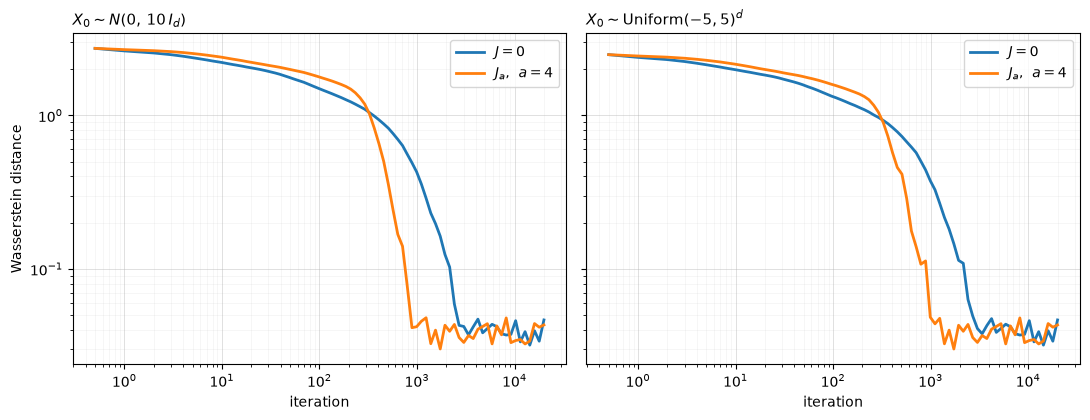

In [11]:
PRIOR_TITLE = {"normal10": r"$X_0 \sim N(0,\,10\,I_d)$",
               "uniform5": r"$X_0 \sim \mathrm{Uniform}(-5,5)^d$"}

it = np.asarray(record_at, dtype=float)
it[0] = it[1] / 2                       # first point is iteration 0; nudge onto the log axis

fig, axes = plt.subplots(1, len(PRIORS), figsize=(11.0, 4.3), sharey=True)
axes = np.atleast_1d(axes)
for ax, prior in zip(axes, PRIORS):
    ax.plot(it, curves[prior]["zero"],  lw=2.0, label=r"$J = 0$")
    ax.plot(it, curves[prior]["const"], lw=2.0, label=rf"$J_a$,  $a = {A:g}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("iteration")
    ax.set_title(PRIOR_TITLE[prior], loc="left", fontsize=11)
    ax.grid(True, which="major", lw=0.6, alpha=0.45)
    ax.grid(True, which="minor", lw=0.4, alpha=0.20)
    ax.set_axisbelow(True)              # gridlines behind the curves
    ax.legend()
axes[0].set_ylabel("Wasserstein distance")
fig.tight_layout()
fig.savefig("anchored_mcp_target.png", dpi=200)
plt.show()

In [12]:
# the same two panels as standalone figures
for prior in PRIORS:
    fig, ax = plt.subplots(figsize=(6.6, 4.4))
    ax.plot(it, curves[prior]["zero"],  lw=2.0, label=r"$J = 0$")
    ax.plot(it, curves[prior]["const"], lw=2.0, label=rf"$J_a$,  $a = {A:g}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("iteration")
    ax.set_ylabel("Wasserstein distance")
    ax.grid(True, which="major", lw=0.6, alpha=0.45)
    ax.grid(True, which="minor", lw=0.4, alpha=0.20)
    ax.set_axisbelow(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"anchored_mcp_target_{prior}.png", dpi=200)
    plt.close(fig)
print("wrote", ", ".join(f"anchored_mcp_target_{p}.png" for p in PRIORS))

wrote anchored_mcp_target_normal10.png, anchored_mcp_target_uniform5.png
